In [1]:
# Required: pip install scikit-learn nltk matplotlib pandas
# Optional: pip install spacy bertopic sentence-transformers umap-learn hdbscan
# After installing nltk run once: nltk.download('wordnet') and nltk.download('omw-1.4')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation, NMF

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Core imports done.')

Core imports done.


In [2]:
# load data — AA rows only, drop missing abstracts
BASE_PATH = './data/'
abstract_raw = pd.read_excel(BASE_PATH + 'grants-with-abstract.xlsx',
                             sheet_name='Grants with abstract (2).csv')

aa = abstract_raw[abstract_raw['Sourcetype'] == 'AA'].copy()
aa = aa.dropna(subset=['Abstract'])
aa['Start Date'] = pd.to_datetime(aa['Start Date'], errors='coerce')
aa['Year'] = aa['Start Date'].dt.year

print(f'Total raw rows       : {len(abstract_raw):,}')
print(f'AA rows              : {(abstract_raw["Sourcetype"]=="AA").sum():,}')
print(f'AA with abstract     : {len(aa):,}')
print(f'Year range           : {int(aa["Year"].min())} – {int(aa["Year"].max())}')

Total raw rows       : 8,075
AA rows              : 3,583
AA with abstract     : 2,873
Year range           : 1995 – 2026


In [3]:
# remove NSF boilerplate sections
# 42% of abstracts contain standard NSF template text ("Intellectual Merit" / "Broader Impacts")
# These sections add zero topic signal and pollute every model
def remove_nsf_boilerplate(text):
    if not isinstance(text, str):
        return ''
    # Remove from 'Intellectual Merit' header to end or to 'Broader Impacts'
    text = re.sub(r'(?i)intellectual\s+merit\s*[:.*\-]?.*?(broader\s+impacts|$)',
                  ' ', text, flags=re.DOTALL)
    # Remove remaining 'Broader Impacts' section to end
    text = re.sub(r'(?i)broader\s+impacts\s*[:.*\-]?.*', ' ', text, flags=re.DOTALL)
    return text.strip()

before = aa['Abstract'].str.contains('Intellectual Merit|Broader Impacts', case=False, na=False).sum()
aa['abstract_clean'] = aa['Abstract'].apply(remove_nsf_boilerplate)
after = aa['abstract_clean'].str.contains('Intellectual Merit|Broader Impacts', case=False, na=False).sum()

print(f'Abstracts with NSF boilerplate before : {before:,}')
print(f'Remaining after removal               : {after:,}')

Abstracts with NSF boilerplate before : 1,210
Remaining after removal               : 0


In [4]:
#  main text cleaning function
# Fixes HTML entities (&gt; &lt; &amp;), lowercases, removes numbers,
# punctuation, URLs, and words shorter than 3 characters

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)       # strip HTML tags like <br> <p>
    text = re.sub(r'&\w+;', ' ', text)
    text = text.lower()
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'-', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\b\w{1,2}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

aa['full_text_clean'] = (
    aa['Title'].fillna('').apply(clean_text) + ' ' +
    aa['abstract_clean'].fillna('').apply(clean_text)
)

print('Text cleaning done.')
print('\nSample — original abstract (first 200 chars):')
print(aa['Abstract'].iloc[0][:200])
print('\nSample — after cleaning:')
print(aa['full_text_clean'].iloc[0][:200])

Text cleaning done.

Sample — original abstract (first 200 chars):
Secure multi-party computation (MPC) allows several mutually untrusting parties to perform joint computations while keeping their inputs private. This project develops new techniques for constructing 

Sample — after cleaning:
twc small collaborative iterative approach secure computation secure multi party computation mpc allows several mutually untrusting parties perform joint computations while keeping their inputs privat


In [5]:
# lemmatization — reduce words to their base form
# 'running' → 'run', 'cells' → 'cell', 'algorithms' → 'algorithm'
# This reduces vocabulary size and merges duplicate signal
# Requires: pip install nltk, then run nltk.download('wordnet') once
try:
    import nltk
    from nltk.stem import WordNetLemmatizer
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)

    lemmatizer = WordNetLemmatizer()

    def lemmatize_text(text):
        return ' '.join(lemmatizer.lemmatize(word) for word in text.split())

    aa['full_text_lemma'] = aa['full_text_clean'].apply(lemmatize_text)
    USE_LEMMA = True
    print('Lemmatization done.')
    print('\nSample — after lemmatization:')
    print(aa['full_text_lemma'].iloc[0][:200])

except ImportError:
    print('nltk not installed — skipping lemmatization.')
    print('Run: pip install nltk')
    aa['full_text_lemma'] = aa['full_text_clean']
    USE_LEMMA = False

Lemmatization done.

Sample — after lemmatization:
twc small collaborative iterative approach secure computation secure multi party computation mpc allows several mutually untrusting party perform joint computation while keeping their input private th


In [6]:
#  build stopword list
# Layer 1: standard English words (the, and, is, of, it, this ...)
# Layer 2: NSF/grant boilerplate words that survive cleaning
# Layer 3: words so generic they appear in every topic (data, model, system ...)
# Layer 4: HTML artifact words just in case any survive

grant_noise = {
    # Grant/proposal language
    'research', 'project', 'award', 'grant', 'proposal', 'funded', 'funding',
    'investigator', 'principal', 'collaborative', 'collaboration', 'team',
    'work', 'working', 'study', 'studies', 'aims', 'aim', 'goal', 'goals',
    'proposed', 'propose', 'objective', 'objectives', 'researcher',
    # University/admin language
    'university', 'northeastern', 'national', 'science', 'engineering',
    'foundation', 'center', 'institute', 'program', 'programs',
    'support', 'supported', 'faculty', 'student', 'students', 'graduate',
    'undergraduate', 'education', 'educational', 'laboratory', 'lab', 'user',
    'conference', 'workshop', 'training', 'infrastructure', 'activities',
    'activity', 'mission', 'scientific', 'data', 'device', 'tool', 'method',
    'analysis', 'technique', 'area', 'technology', 'school', 'college',
    # Generic verbs/adjectives with no topic meaning
    'develop', 'development', 'developed', 'developing',
    'provide', 'provides', 'provided', 'providing',
    'include', 'including', 'includes', 'included',
    'approach', 'approaches', 'novel', 'new', 'enable', 'enabled',
    'use', 'used', 'using', 'uses', 'based',
    'result', 'results', 'resulting', 'impact', 'impacts',
    'important', 'significant', 'key', 'critical', 'potential',
    'ability', 'demonstrate', 'understand', 'understanding',
    'require', 'required', 'design', 'implement', 'implementation',
    'explore', 'consider', 'address', 'advance', 'advances', 'advanced',
    'high', 'large', 'small', 'specific', 'general', 'current', 'real',
    'different', 'multiple', 'fundamental', 'future', 'complex', 'effect',
    'knowledge', 'performance', 'framework', 'process', 'processes', 'need',
    'public', 'community', 'multi', 'groups', 'group',
    'time', 'state', 'level', 'scale', 'field',
    'represent', 'representation', 'model', 'change', 'changes',
    'problem', 'problems', 'experiment', 'challenge', 'open',
    # NSF boilerplate survivors
    'intellectual', 'merit', 'broader', 'criteria', 'criterion', 'deemed',
    'worthy', 'statutory', 'reflects', 'review',
    # HTML artifact words
    'andgt', 'andlt', 'nbsp', 'amp', 'br',
    # Short non-informative words that slip past the 2-char filter
    'will', 'also', 'well', 'can', 'may', 'such', 'thus',
    'this', 'these', 'their', 'been', 'have', 'from',
    # Lemmatization artifacts
    'ha',
    # Agency/program names
    'nsf', 'reu', 'stem',
    # NSF broader impacts / education boilerplate
    'participant', 'opportunity', 'diverse', 'diversity', 'minority',
    'institution', 'professional', 'career', 'experience',
    # Conference travel artifacts
    'travel', 'attend', 'attending', 'international', 'held', 'conext',
    # Location/admin artifacts
    'site', 'boston', 'ethic',
}

all_stops = list(set(ENGLISH_STOP_WORDS) | grant_noise)
print(f'Total stopwords: {len(all_stops):,}')

Total stopwords: 507


In [7]:
# inspect remaining top words — confirm cleaning worked
# If you still see noise words, add them to grant_noise above and re-run from Step 4
all_words = ' '.join(aa['full_text_lemma']).split()
freq = Counter(w for w in all_words if w not in all_stops and len(w) > 3)

print('Top 60 content words after full cleaning pipeline:')
for word, count in freq.most_common(60):
    print(f'  {word:<25} {count:,}')

Top 60 content words after full cleaning pipeline:
  network                   2,413
  learning                  1,896
  cell                      1,880
  application               1,619
  human                     1,507
  material                  1,428
  information               1,327
  health                    1,271
  evaluation                1,229
  theory                    1,193
  structure                 1,161
  control                   1,098
  environment               1,025
  social                    1,021
  interaction               1,006
  energy                    961
  function                  903
  behavior                  890
  dynamic                   884
  algorithm                 880
  mechanism                 848
  computer                  838
  physic                    815
  communication             812
  focus                     803
  protein                   802
  computational             793
  software                  786
  property             

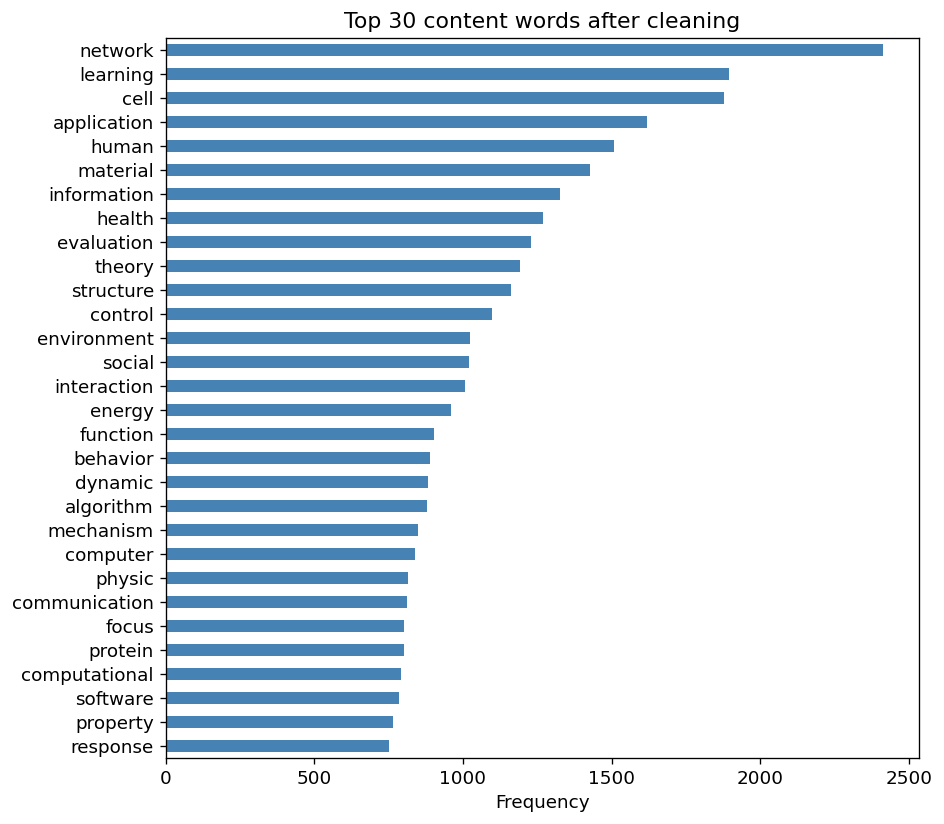

In [8]:
#  bar chart of top 30 content words — visual sanity check
top30 = pd.Series(dict(freq.most_common(30))).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
top30.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Frequency')
ax.set_title('Top 30 content words after cleaning')
plt.tight_layout()
plt.savefig('figures/top_words_clean.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# build vectorizers — one for LDA (counts), one for NMF (TF-IDF)
# min_df=5  : word must appear in at least 5 documents (cuts typos and rare words)
# max_df=0.60: skip words in more than 60% of documents (catches remaining generic words)
# ngram_range=(1,2): use single words and two-word phrases (e.g. 'machine learning', 'neural network')

N_TOPICS = 8  # change this after checking the perplexity chart below

count_vec = CountVectorizer(
    stop_words=all_stops,
    ngram_range=(1, 2),
    max_features=3000,
    min_df=5,
    max_df=0.60
)
tfidf_vec = TfidfVectorizer(
    stop_words=all_stops,
    ngram_range=(1, 2),
    max_features=3000,
    min_df=5,
    max_df=0.60
)

count_matrix = count_vec.fit_transform(aa['full_text_lemma'])
tfidf_matrix = tfidf_vec.fit_transform(aa['full_text_lemma'])

print(f'Vocabulary (count): {len(count_vec.get_feature_names_out()):,} terms')
print(f'Vocabulary (tfidf): {len(tfidf_vec.get_feature_names_out()):,} terms')
print(f'Matrix shape      : {count_matrix.shape}')

Vocabulary (count): 3,000 terms
Vocabulary (tfidf): 3,000 terms
Matrix shape      : (2873, 3000)


## Method 1 — LDA (Latent Dirichlet Allocation)

n= 5  perplexity=1448.0
n= 7  perplexity=1367.3
n= 8  perplexity=1351.3
n=10  perplexity=1320.2
n=12  perplexity=1280.8
n=15  perplexity=1255.6


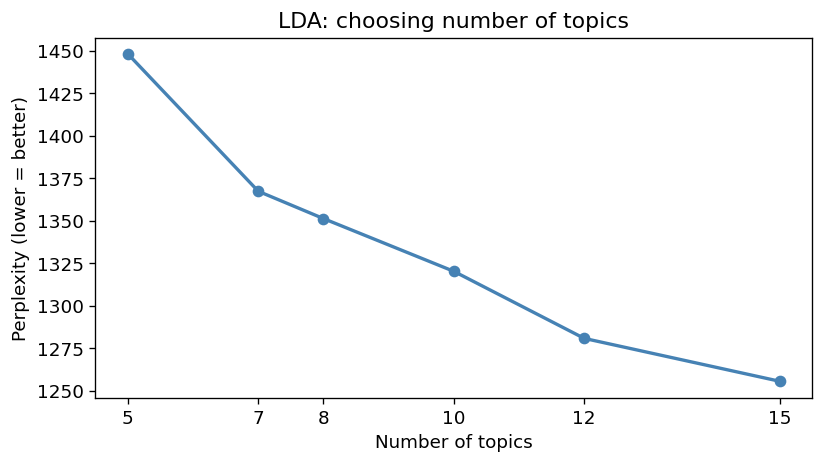

Update N_TOPICS in Step 7 if needed, then re-run.


In [10]:
# LDA: choose number of topics — compare perplexity across n values
# Lower perplexity = better fit. Look for the elbow — where it stops dropping fast.
topic_range  = [5, 7, 8, 10, 12, 15]
perplexities = []

for n in topic_range:
    m = LatentDirichletAllocation(
        n_components=n, max_iter=20,
        learning_method='online', random_state=42, n_jobs=-1
    )
    m.fit(count_matrix)
    p = m.perplexity(count_matrix)
    perplexities.append(p)
    print(f'n={n:2d}  perplexity={p:.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(topic_range, perplexities, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Number of topics')
ax.set_ylabel('Perplexity (lower = better)')
ax.set_title('LDA: choosing number of topics')
ax.set_xticks(topic_range)
plt.tight_layout()
plt.savefig('figures/lda_perplexity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Update N_TOPICS in Step 7 if needed, then re-run.')

In [11]:
# LDA: fit final model with chosen N_TOPICS
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=25,
    learning_method='online',
    random_state=42,
    n_jobs=-1
)
lda_doc_topics = lda.fit_transform(count_matrix)
print(f'LDA fit done. Perplexity: {lda.perplexity(count_matrix):.1f}')

LDA fit done. Perplexity: 1348.7


In [12]:
# LDA: print top words per topic — read these to name your topics
def show_topics(model, vectorizer, n_words=12):
    names = vectorizer.get_feature_names_out()
    for i, topic in enumerate(model.components_):
        words = [names[j] for j in topic.argsort()[:-n_words - 1:-1]]
        print(f'  Topic {i+1:2d}: {" | ".join(words)}')

print(f'LDA Topics (n={N_TOPICS}):')
print()
show_topics(lda, count_vec)

LDA Topics (n=8):

  Topic  1: network | water | environmental | information | health | modeling | risk | human | decision | dynamic | climate | social
  Topic  2: network | wireless | application | software | communication | algorithm | power | sensor | security | spectrum | sensing | hardware
  Topic  3: protein | function | gene | mechanism | molecular | specie | biological | cell | interaction | role | compound | dna
  Topic  4: learning | evaluation | computer | scientist | computing | resource | practice | industry | machine | service | network | build
  Topic  5: material | energy | structure | property | magnetic | application | spin | particle | mechanical | chemical | temperature | experimental
  Topic  6: cell | drug | cancer | brain | imaging | patient | neural | tissue | human | disease | tumor | therapy
  Topic  7: health | human | behavior | intervention | social | individual | learning | task | cognitive | robot | people | child
  Topic  8: theory | physic | quantum | g

In [13]:
# LDA: assign dominant topic to each grant, then add your labels
aa['lda_topic'] = lda_doc_topics.argmax(axis=1)

# Fill in labels after reading the words above
lda_labels = {
    0: 'Environment & Climate',
    1: 'Networking & Communications',
    2: 'Public Health & Society',
    3: 'STEM Education & Broadening Participation',
    4: 'Physics & Materials Science',
    5: 'Cognitive & Computational Modeling',
    6: 'Biomedical & Molecular Biology',
    7: 'AI & Computer Science',
}

aa['lda_label'] = aa['lda_topic'].map(lda_labels)

print('Grant count per LDA topic:')
print(aa['lda_label'].value_counts().to_string())

Grant count per LDA topic:
lda_label
STEM Education & Broadening Participation    631
Networking & Communications                  487
Physics & Materials Science                  354
Public Health & Society                      343
Biomedical & Molecular Biology               333
Environment & Climate                        265
Cognitive & Computational Modeling           258
AI & Computer Science                        202


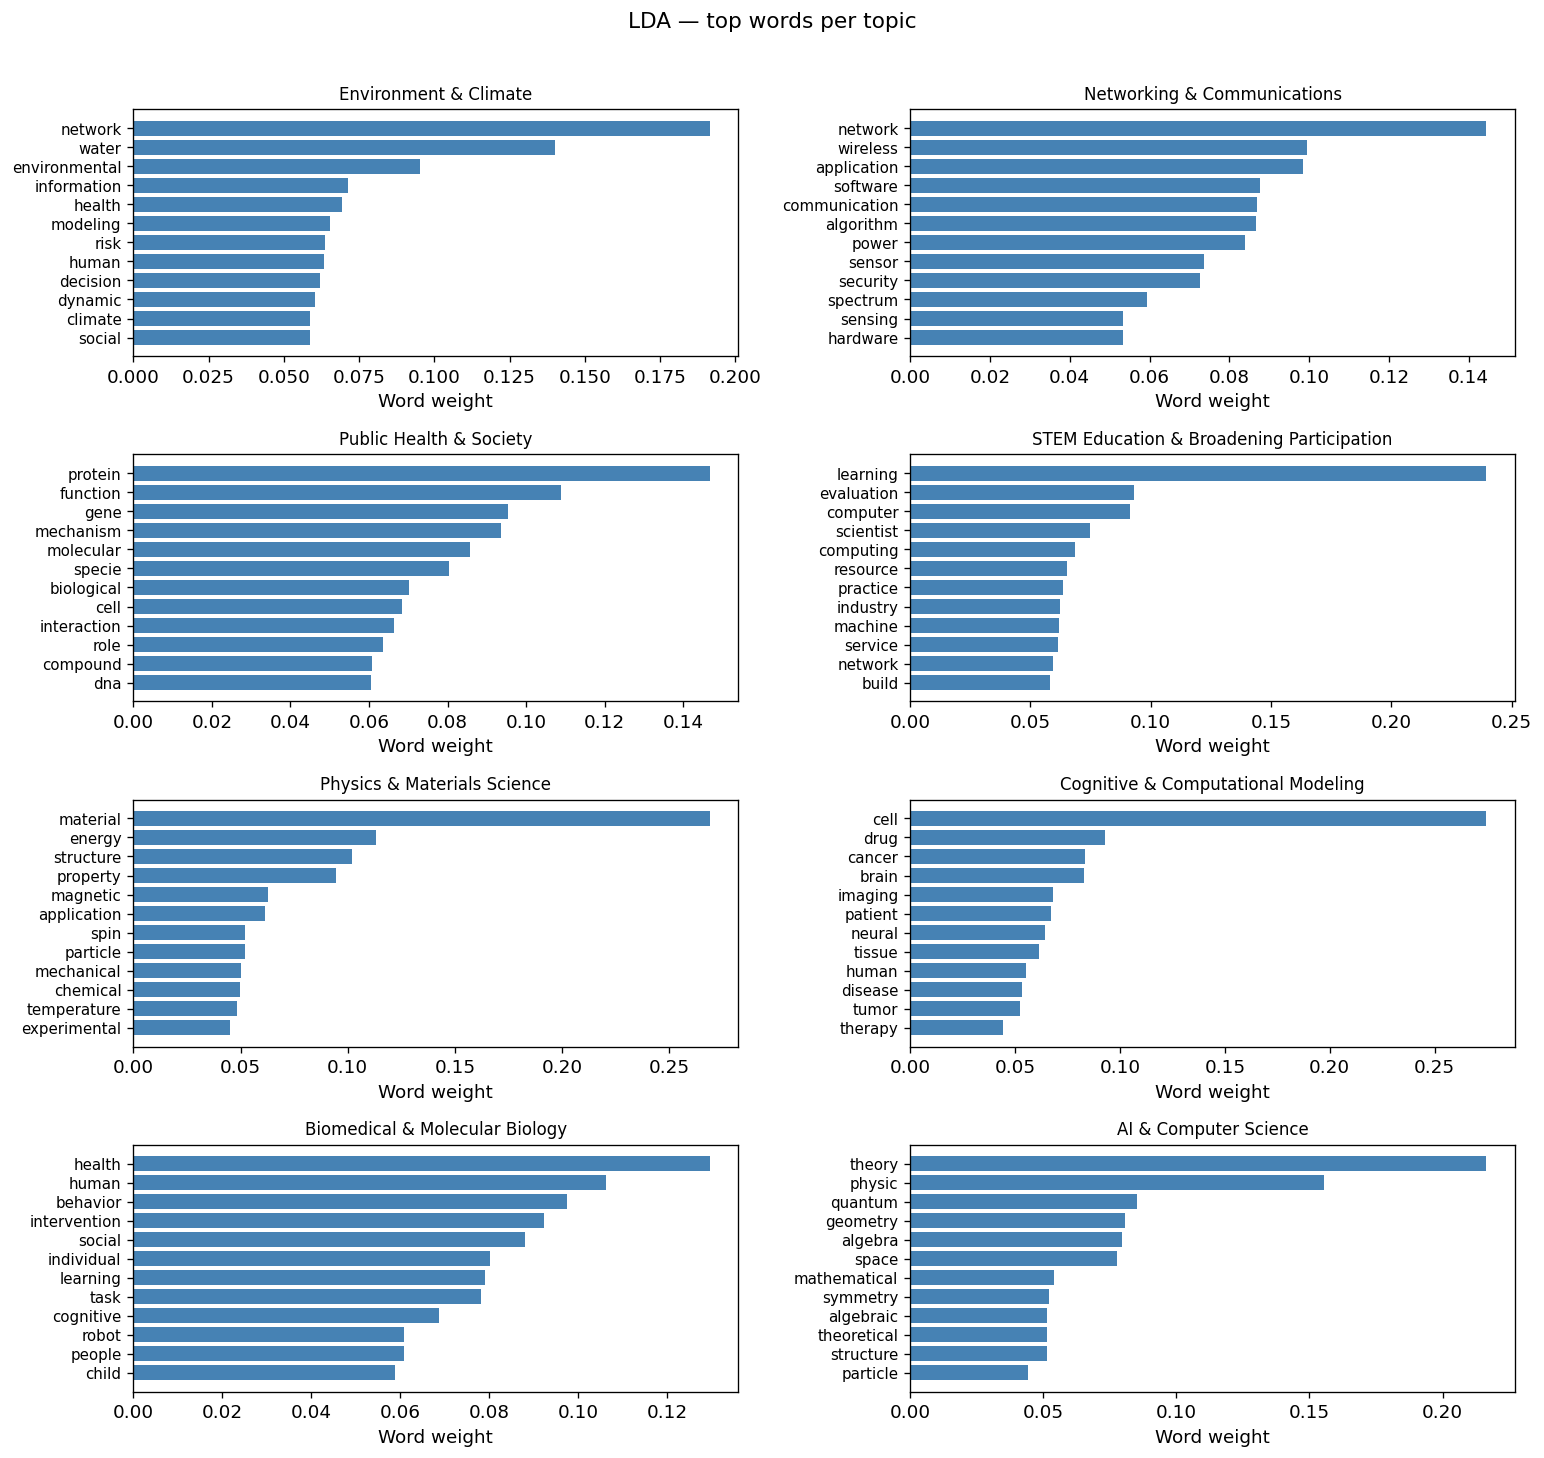

In [14]:
# LDA: word-weight grid — one panel per topic for easy visual reading
lda_names = count_vec.get_feature_names_out()
n_cols = 2
n_rows = (N_TOPICS + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 3))
axes = axes.flatten()

for i, topic in enumerate(lda.components_):
    top_idx   = topic.argsort()[:-13:-1]
    top_words = [lda_names[j] for j in top_idx]
    top_vals  = topic[top_idx] / topic[top_idx].sum()
    axes[i].barh(range(12), top_vals[::-1], color='steelblue')
    axes[i].set_yticks(range(12))
    axes[i].set_yticklabels(top_words[::-1], fontsize=9)
    axes[i].set_title(lda_labels.get(i, f'Topic {i+1}'), fontsize=10)
    axes[i].set_xlabel('Word weight')

for j in range(N_TOPICS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('LDA — top words per topic', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('figures/lda_topic_words.png', dpi=150, bbox_inches='tight')
plt.show()

Funding per LDA topic:
                                           num_grants  total_M   avg_K
lda_label                                                             
AI & Computer Science                             202     78.1   387.0
Physics & Materials Science                       354    233.3   659.0
Cognitive & Computational Modeling                258    282.6  1095.0
Networking & Communications                       487    332.1   682.0
Biomedical & Molecular Biology                    333    431.6  1296.0
Environment & Climate                             265    438.6  1655.0
Public Health & Society                           343    473.7  1381.0
STEM Education & Broadening Participation         631    642.0  1017.0


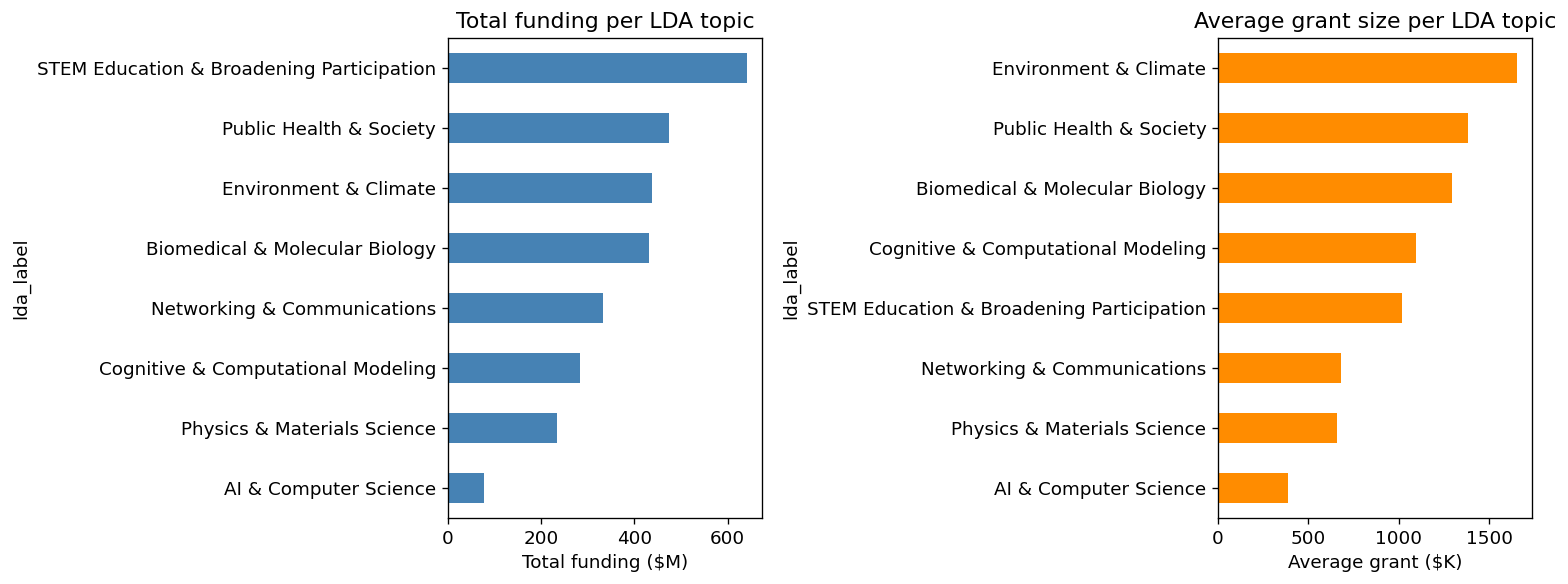

In [15]:
# LDA: funding per topic — how much money does each theme attract?
lda_funding = (
    aa.groupby('lda_label')['Dollar Amount']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'total', 'count': 'num_grants', 'mean': 'avg'})
    .sort_values('total', ascending=True)
)
lda_funding['total_M'] = (lda_funding['total'] / 1e6).round(1)
lda_funding['avg_K']   = (lda_funding['avg']   / 1e3).round(0)

print('Funding per LDA topic:')
print(lda_funding[['num_grants', 'total_M', 'avg_K']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lda_funding['total_M'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total funding ($M)')
axes[0].set_title('Total funding per LDA topic')
lda_funding['avg_K'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Average grant ($K)')
axes[1].set_title('Average grant size per LDA topic')
plt.tight_layout()
plt.savefig('figures/lda_funding.png', dpi=150, bbox_inches='tight')
plt.show()

## Method 2 — NMF (Non-negative Matrix Factorization)

In [16]:
# NMF: fit model on TF-IDF matrix
# NMF tends to give cleaner, more distinct topics than LDA
# Uses same N_TOPICS as LDA for direct comparison
nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=400)
nmf_doc_topics = nmf.fit_transform(tfidf_matrix)
print('NMF fit done.')

NMF fit done.


In [17]:
# NMF: print top words per topic
print(f'NMF Topics (n={N_TOPICS}):')
print()
show_topics(nmf, tfidf_vec)

NMF Topics (n=8):

  Topic  1: learning | robot | task | machine | machine learning | human | brain | algorithm | neural | physical | game | control
  Topic  2: cell | cancer | tumor | drug | tissue | protein | gene | therapy | function | disease | cellular | molecular
  Topic  3: theory | algebra | geometry | algebraic | quantum | algebraic geometry | symmetry | space | mathematics | invariant | modulus | modulus space
  Topic  4: network | wireless | communication | spectrum | algorithm | security | wireless network | networking | protocol | layer | sensor | power
  Topic  5: material | magnetic | property | energy | structure | protein | spin | quantum | film | electron | temperature | optical
  Topic  6: health | water | social | environmental | risk | intervention | information | behavior | coastal | policy | human | population
  Topic  7: physic | particle | particle physic | lhc | energy | higgs | collider | cm | hadron | hadron collider | standard | string
  Topic  8: language 

In [18]:
# NMF: assign dominant topic and add labels
aa['nmf_topic'] = nmf_doc_topics.argmax(axis=1)

nmf_labels = {
    0: 'AI & Machine Learning',
    1: 'Biomedical & Cancer Biology',
    2: 'Pure Mathematics',
    3: 'Networking & Communications',
    4: 'Materials Science & Condensed Matter',
    5: 'Public Health, Environment & Climate',
    6: 'Particle Physics',
    7: 'STEM Education & Broadening Participation',
}
aa['nmf_label'] = aa['nmf_topic'].map(nmf_labels)

print('Grant count per NMF topic:')
print(aa['nmf_label'].value_counts().to_string())

Grant count per NMF topic:
nmf_label
Public Health, Environment & Climate         914
Materials Science & Condensed Matter         474
Biomedical & Cancer Biology                  364
Networking & Communications                  353
AI & Machine Learning                        294
STEM Education & Broadening Participation    254
Pure Mathematics                             139
Particle Physics                              81


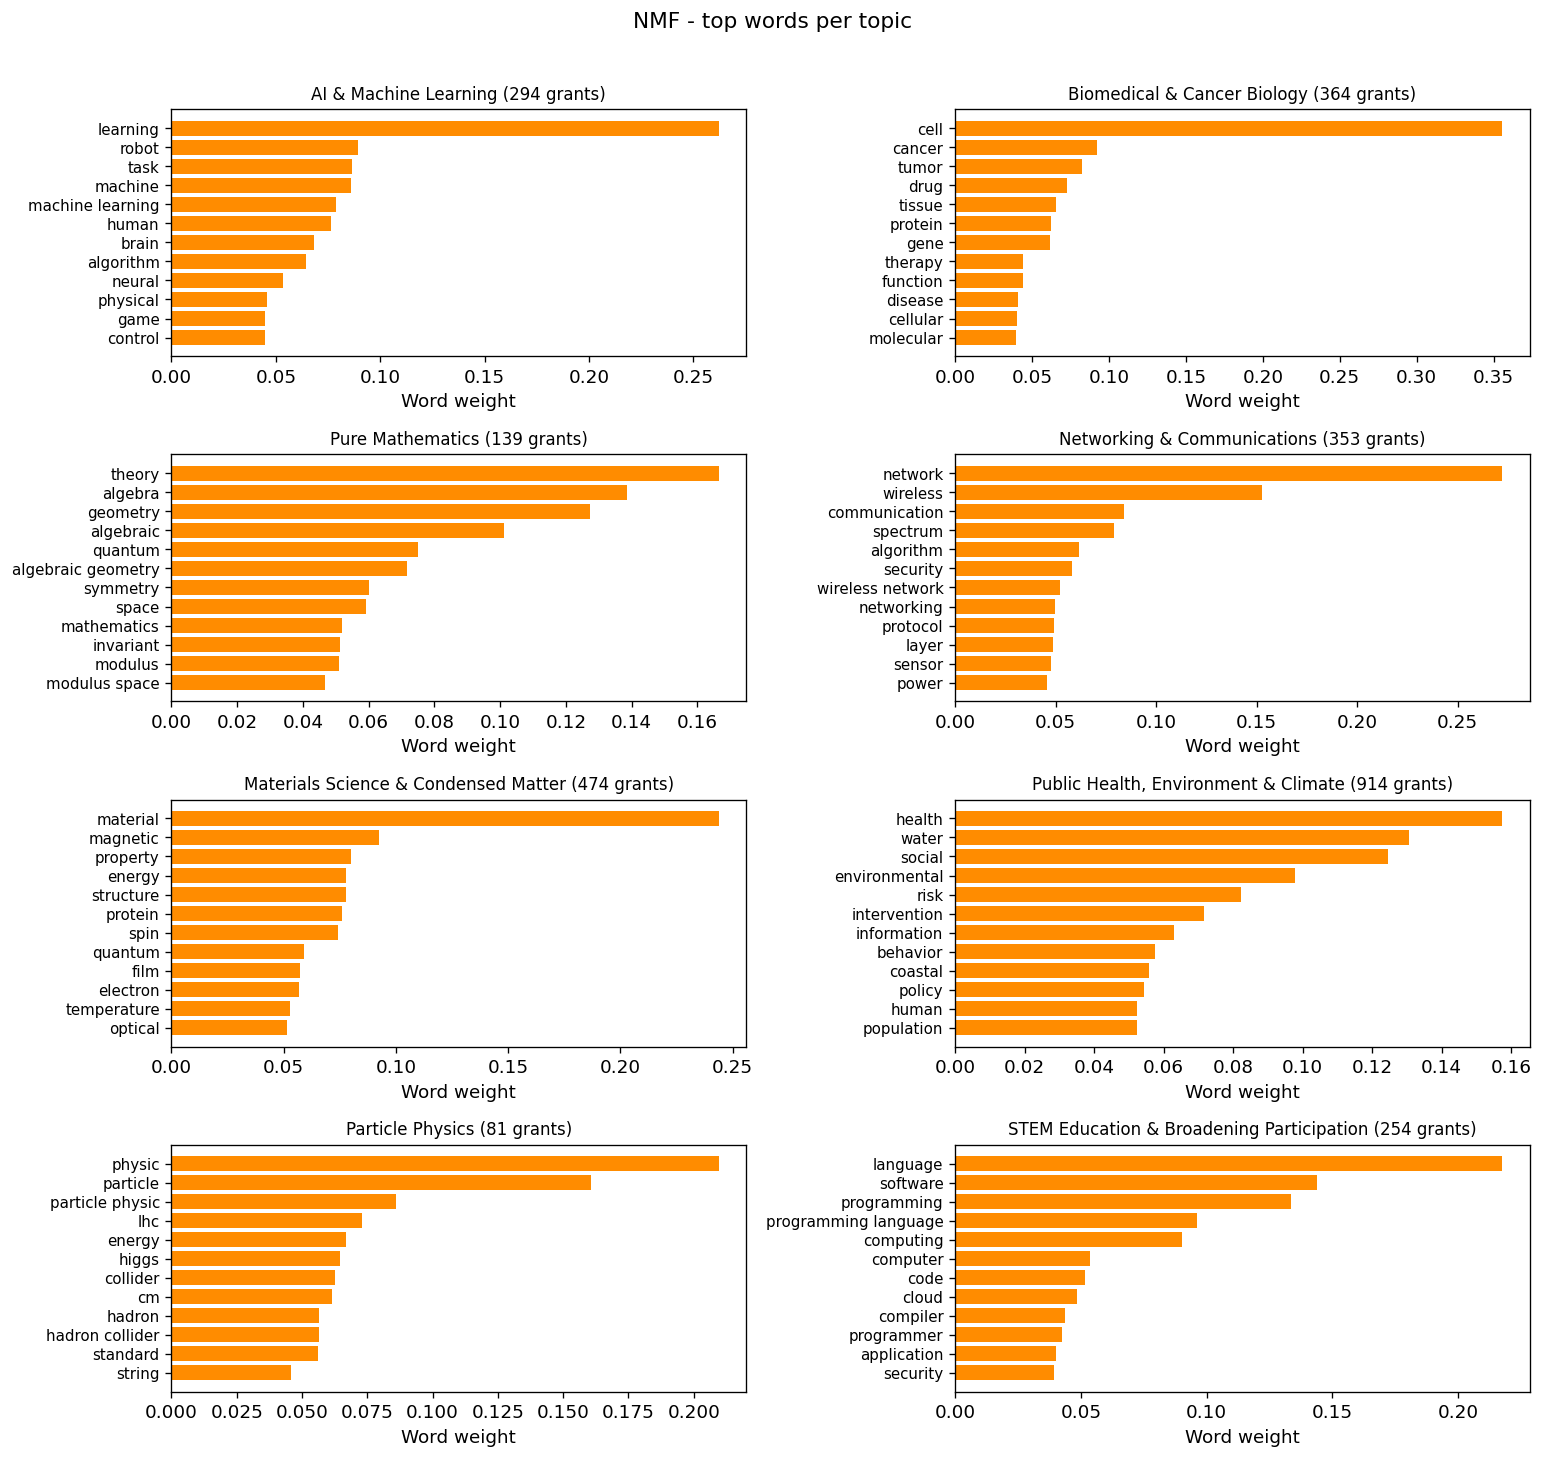

In [31]:
# NMF: word-weight grid (same layout as LDA — easy to compare side by side)
nmf_names = tfidf_vec.get_feature_names_out()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 3))
axes = axes.flatten()

for i, topic in enumerate(nmf.components_):
    top_idx   = topic.argsort()[:-13:-1]
    top_words = [nmf_names[j] for j in top_idx]
    top_vals  = topic[top_idx] / topic[top_idx].sum()
    
    n_grants  = (aa['nmf_topic'] == i).sum()  # count grants in this topic
    
    axes[i].barh(range(12), top_vals[::-1], color='darkorange')
    axes[i].set_yticks(range(12))
    axes[i].set_yticklabels(top_words[::-1], fontsize=9)
    axes[i].set_title(f"{nmf_labels.get(i, f'Topic {i+1}')} ({n_grants} grants)", fontsize=10)
    axes[i].set_xlabel('Word weight')

for j in range(N_TOPICS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('NMF - top words per topic', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('./figures/nmf_topic_words.png', dpi=150, bbox_inches='tight')
plt.show()

Funding per NMF topic:
                                           num_grants  total_M   avg_K
nmf_label                                                             
Pure Mathematics                                  139     38.4   276.0
Particle Physics                                   81     81.7  1008.0
STEM Education & Broadening Participation         254    165.3   651.0
AI & Machine Learning                             294    204.0   694.0
Materials Science & Condensed Matter              474    310.0   654.0
Networking & Communications                       353    316.0   895.0
Biomedical & Cancer Biology                       364    572.0  1571.0
Public Health, Environment & Climate              914   1224.7  1340.0


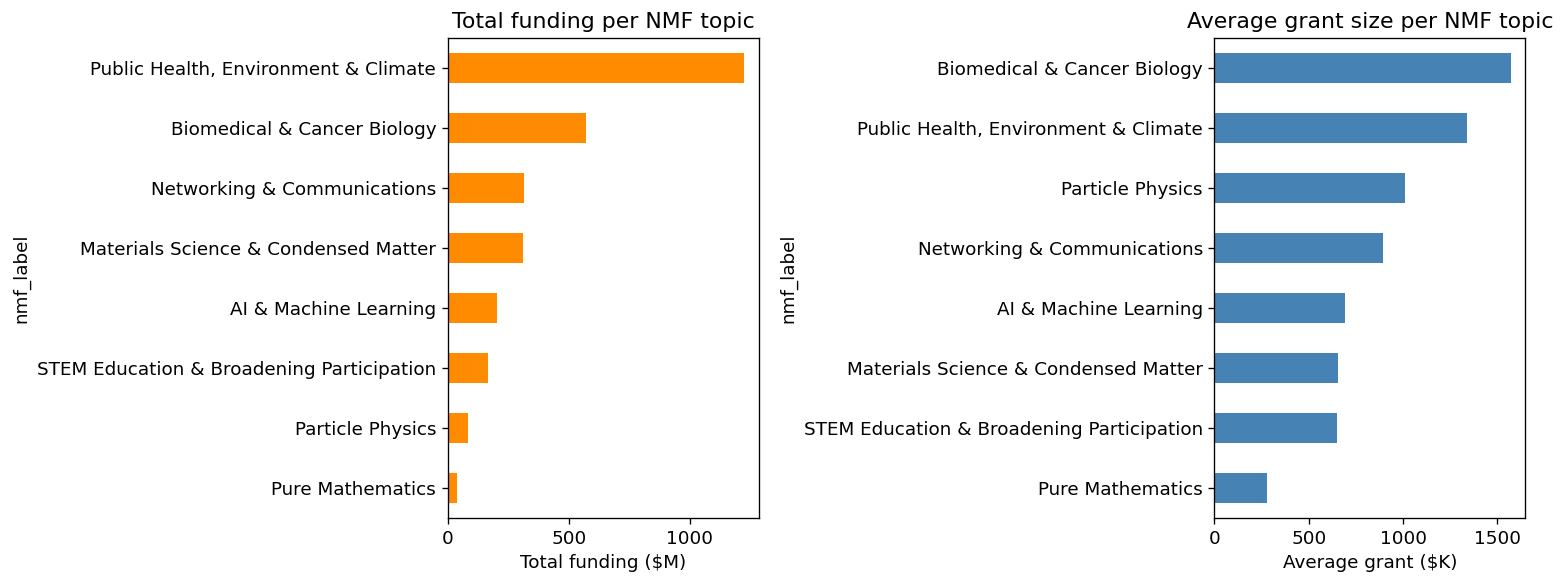

In [20]:
# NMF: funding per topic
nmf_funding = (
    aa.groupby('nmf_label')['Dollar Amount']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'total', 'count': 'num_grants', 'mean': 'avg'})
    .sort_values('total', ascending=True)
)
nmf_funding['total_M'] = (nmf_funding['total'] / 1e6).round(1)
nmf_funding['avg_K']   = (nmf_funding['avg']   / 1e3).round(0)

print('Funding per NMF topic:')
print(nmf_funding[['num_grants', 'total_M', 'avg_K']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
nmf_funding['total_M'].plot(kind='barh', ax=axes[0], color='darkorange')
axes[0].set_xlabel('Total funding ($M)')
axes[0].set_title('Total funding per NMF topic')
nmf_funding['avg_K'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Average grant ($K)')
axes[1].set_title('Average grant size per NMF topic')
plt.tight_layout()
plt.savefig('figures/nmf_funding.png', dpi=150, bbox_inches='tight')
plt.show()

## Method 3 — BERTopic

In [21]:
try:
    from bertopic import BERTopic
    BERT_OK = True
    print('BERTopic ready.')
except ImportError:
    BERT_OK = False

BERTopic ready.


In [22]:
# BERTopic fit — pass vectorizer with stopwords so topic words are clean
# vectorizer_model tells BERTopic which words to use when labeling topics
# without this, labels default to raw text tokens (the, and, of ...)
if BERT_OK:
    from sklearn.feature_extraction.text import CountVectorizer as CV
    bert_vectorizer = CV(
        stop_words=all_stops,
        ngram_range=(1, 2)
    )

    aa['full_text_orig'] = aa['Title'].fillna('') + ' ' + aa['abstract_clean'].fillna('')
    docs = aa['full_text_orig'].tolist()

    bert = BERTopic(
        embedding_model='all-MiniLM-L6-v2',
        vectorizer_model=bert_vectorizer,
        nr_topics=10,
        min_topic_size=30,
        verbose=True
    )
    bert_topics, _ = bert.fit_transform(docs)
    aa['bert_topic'] = bert_topics

    n_found   = bert.get_topic_info().shape[0] - 1
    n_outlier = (aa['bert_topic'] == -1).sum()
    print(f'Topics found  : {n_found}')
    print(f'Outlier docs  : {n_outlier} ({n_outlier/len(aa)*100:.1f}%)')
else:
    print('Skipping.')

2026-06-20 16:17:03,098 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 90/90 [00:14<00:00,  6.19it/s]
2026-06-20 16:17:19,165 - BERTopic - Embedding - Completed ✓
2026-06-20 16:17:19,165 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-06-20 16:17:27,120 - BERTopic - Dimensionality - Completed ✓
2026-06-20 16:17:27,121 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-20 16:17:27,161 - BERTopic - Cluster - Completed ✓
2026-06-20 16:17:27,161 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-20 16:17:27,983 - BERTopic - Representation - Completed ✓
2026-06-20 16:17:27,985 - BERTopic - Topic reduction - Reducing number of topics
2026-06-20 16:17:27,986 - BERTopic - Topic reduction - Number of topics (10) is equal or higher than the clustered topics(4).
2026

Topics found  : 3
Outlier docs  : 12 (0.4%)


In [23]:
# BERTopic: print topic words and grant counts
if BERT_OK:
    topic_info = bert.get_topic_info()
    print('Top BERTopic topics:')
    print(topic_info[topic_info['Topic'] != -1][['Topic', 'Count', 'Name']].head(15).to_string(index=False))
    print()
    for t in topic_info[topic_info['Topic'] != -1]['Topic'].head(12):
        words = bert.get_topic(t)
        print(f'Topic {t:2d}: {" | ".join([w for w, _ in words[:8]])}')

Top BERTopic topics:
 Topic  Count                                    Name
     0   2690    0_systems_learning_information_human
     1     56 1_physics_particle_particle physics_lhc
     2    115    2_theory_geometry_algebras_algebraic

Topic  0: systems | learning | information | human | models | health | network | networks
Topic  1: physics | particle | particle physics | lhc | standard | higgs | cms | collider
Topic  2: theory | geometry | algebras | algebraic | quantum | spaces | algebra | algebraic geometry


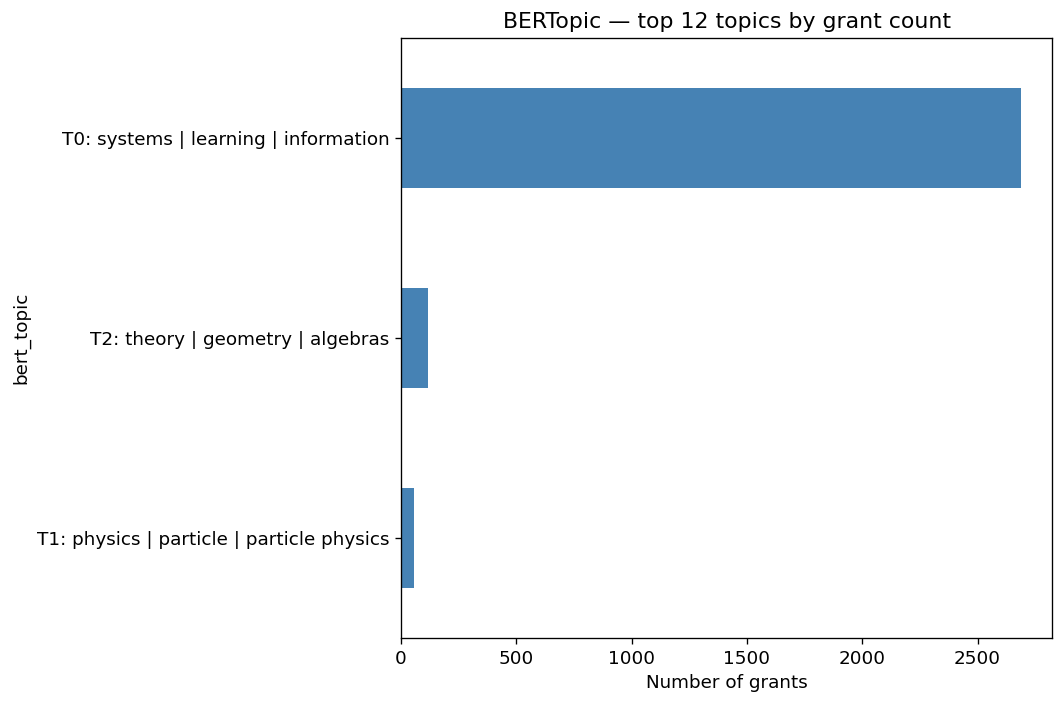

In [24]:
# BERTopic: grant count bar chart
if BERT_OK:
    bert_counts = (
        aa[aa['bert_topic'] != -1]['bert_topic']
        .value_counts().head(12)
        .rename(index=lambda t: f'T{t}: ' + ' | '.join([w for w, _ in bert.get_topic(t)[:3]]))
        .sort_values()
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    bert_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Number of grants')
    ax.set_title('BERTopic — top 12 topics by grant count')
    plt.tight_layout()
    plt.savefig('figures/bertopic_counts.png', dpi=150, bbox_inches='tight')
    plt.show()

Saved: figures/bertopic_barchart.html + figures/bertopic_barchart.png
Saved: figures/bertopic_map.html + figures/bertopic_map.png
Saved: figures/bertopic_heatmap.html + figures/bertopic_heatmap.png
--- bertopic_barchart ---


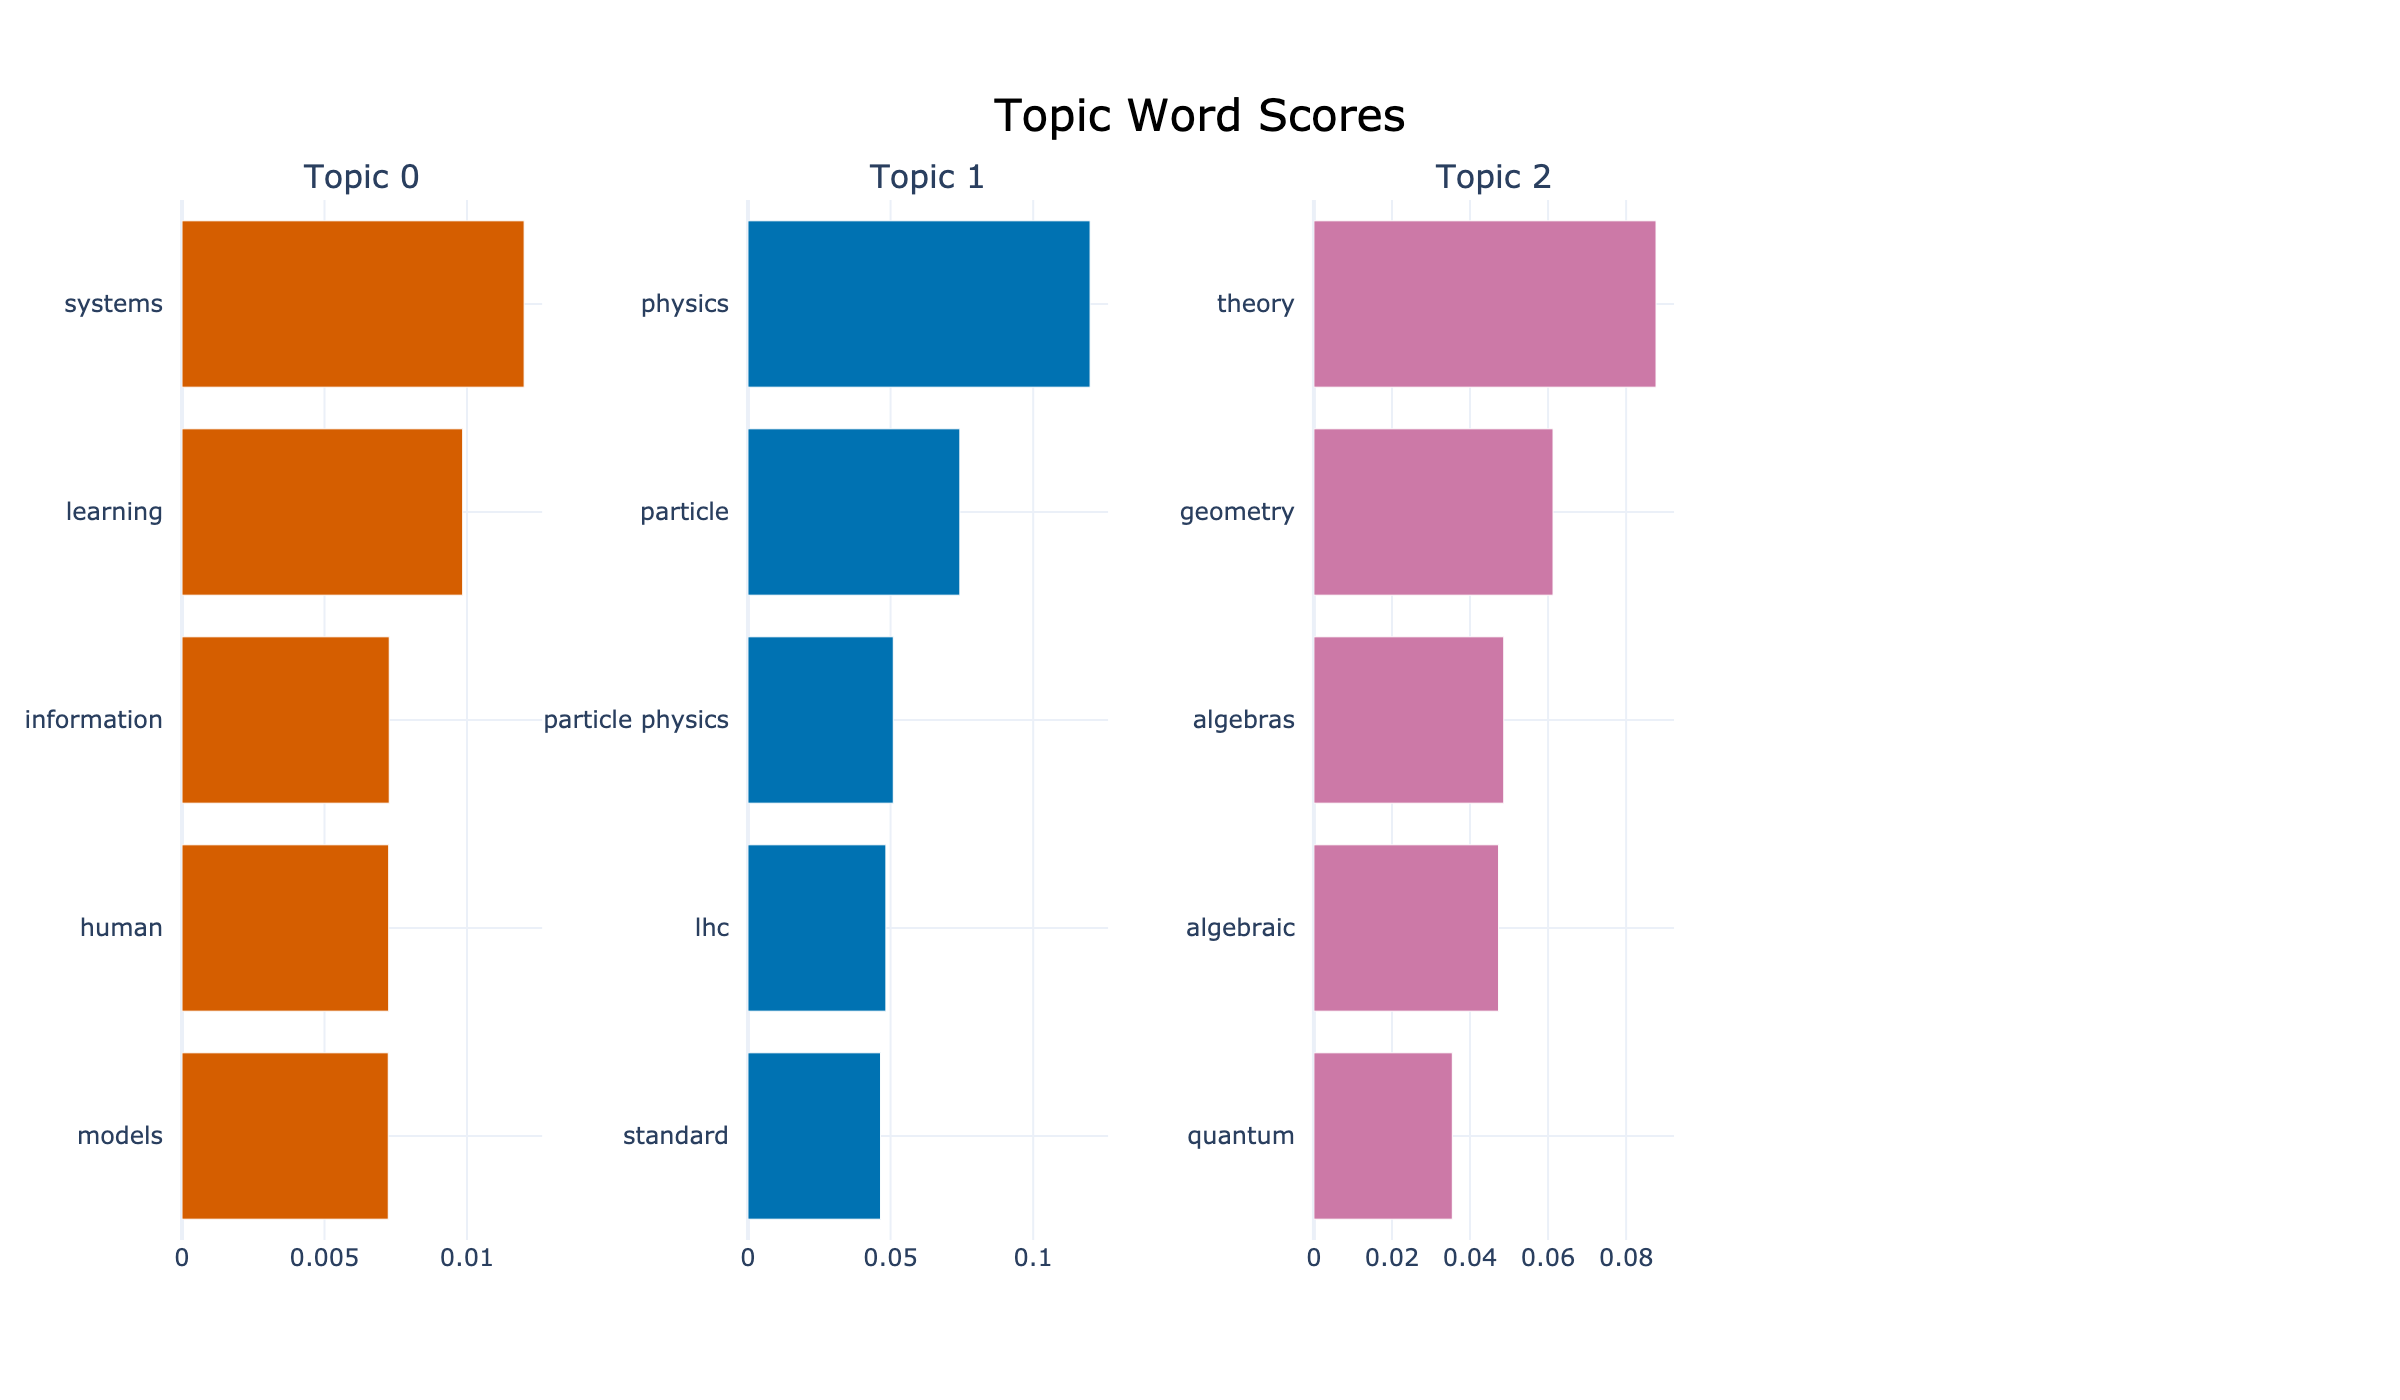

--- bertopic_map ---


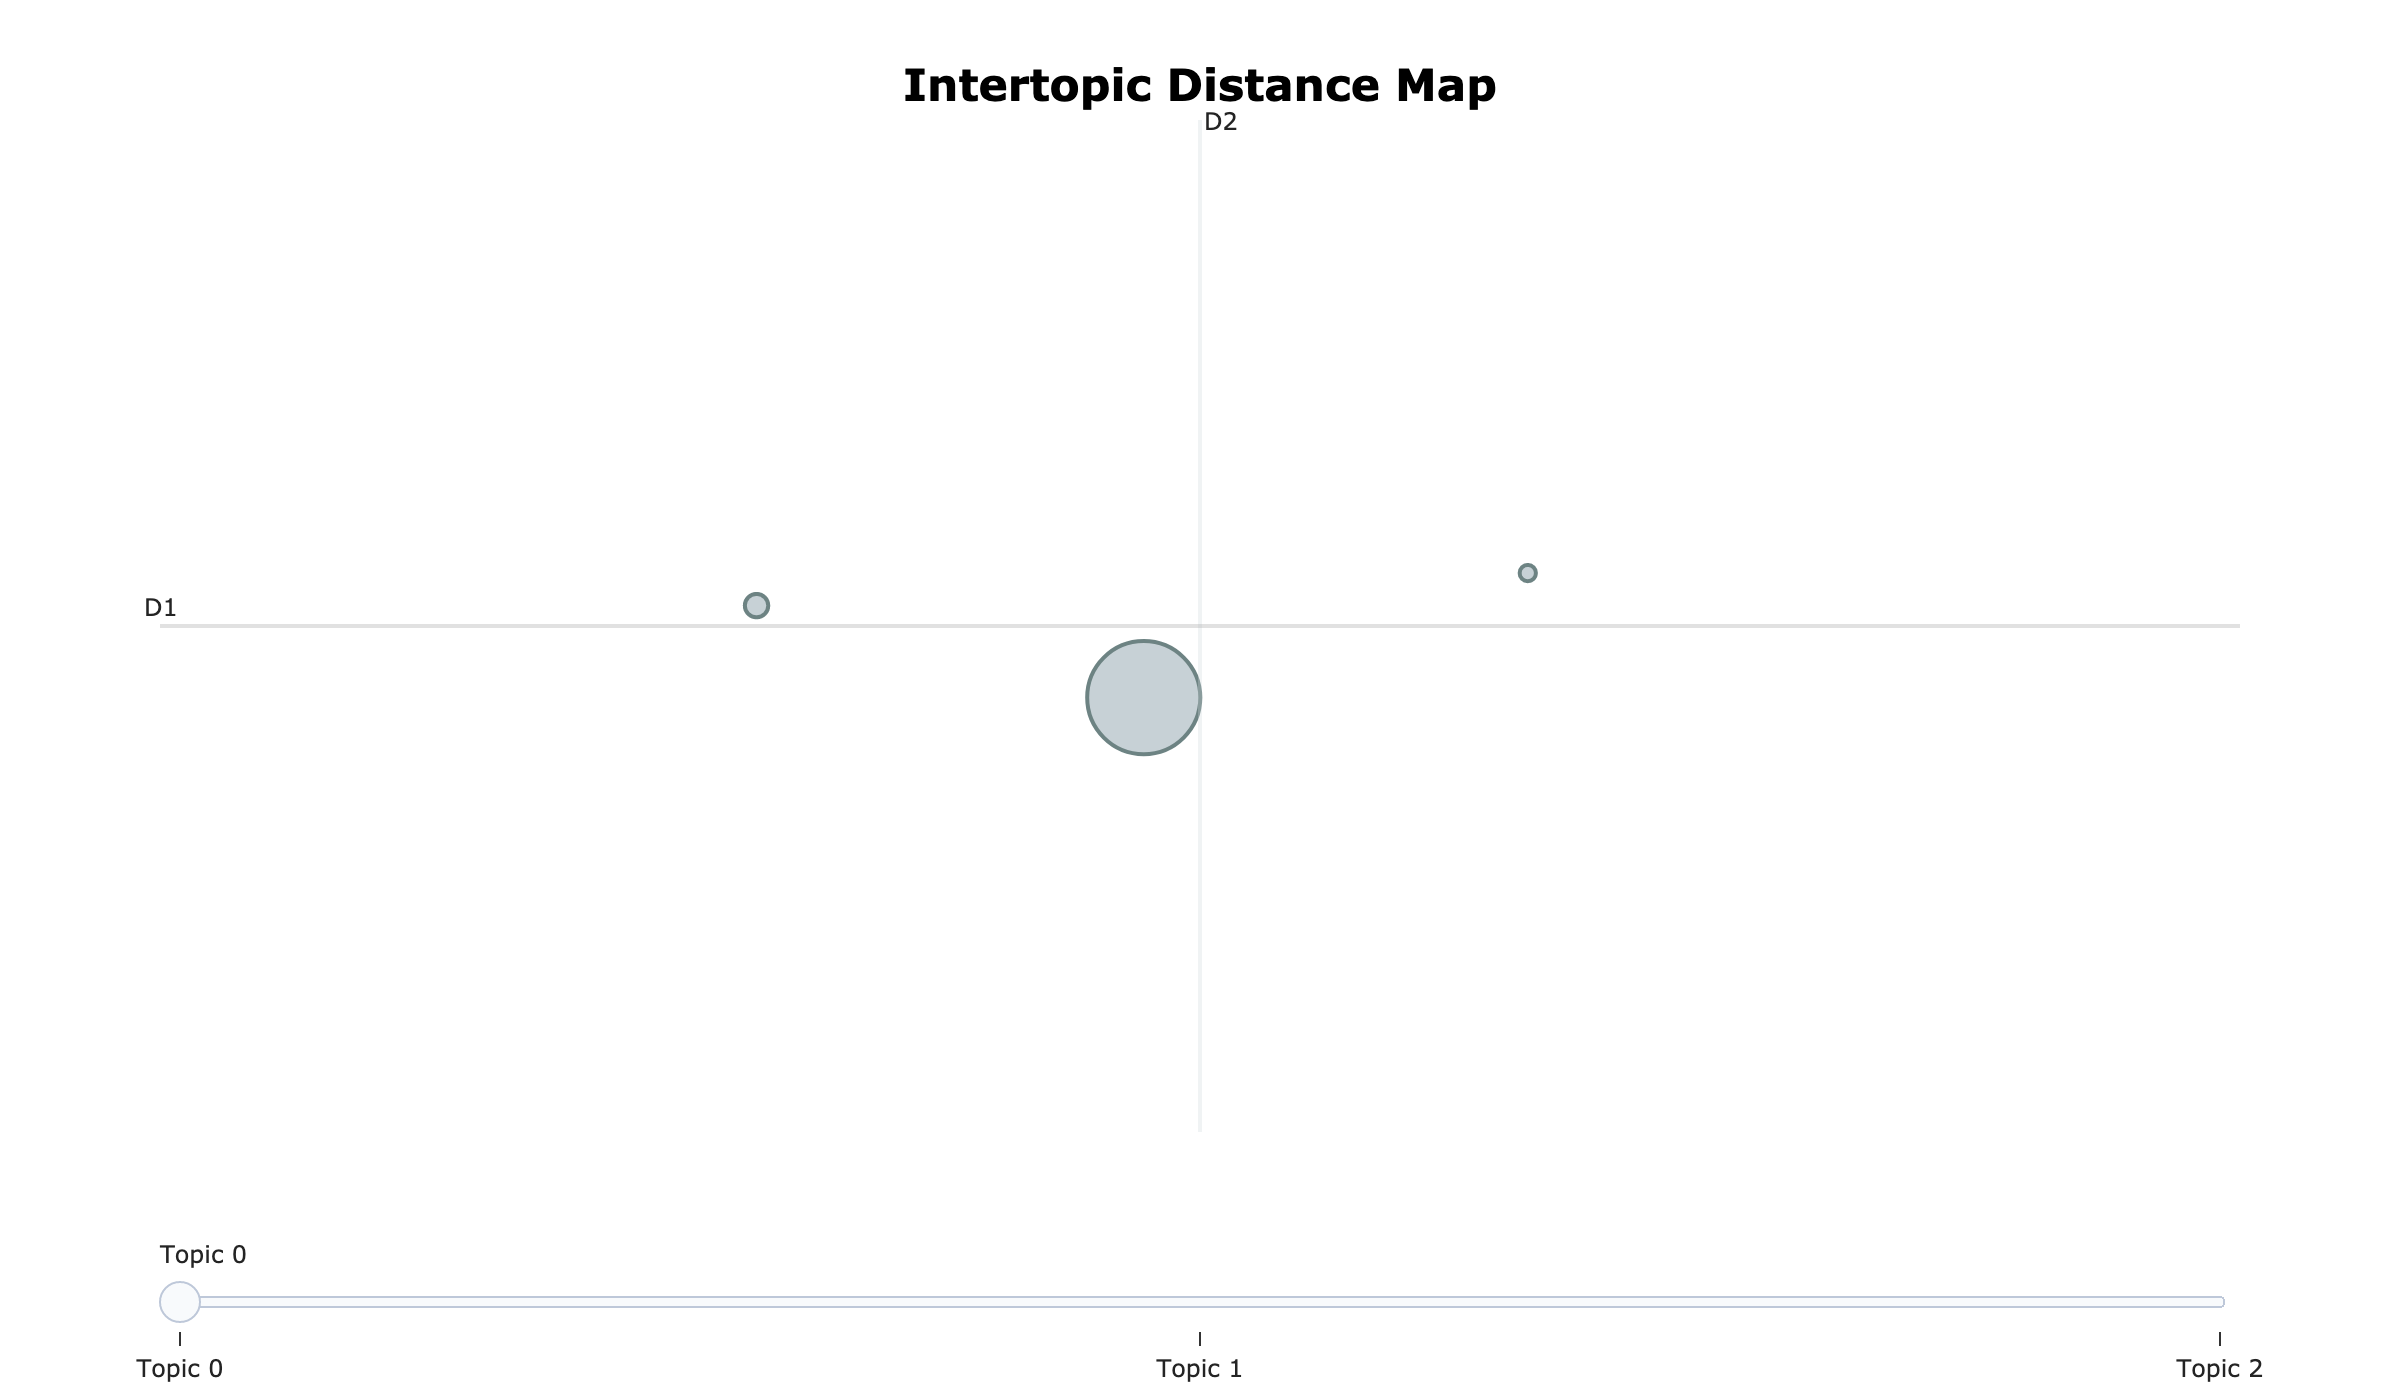

--- bertopic_heatmap ---


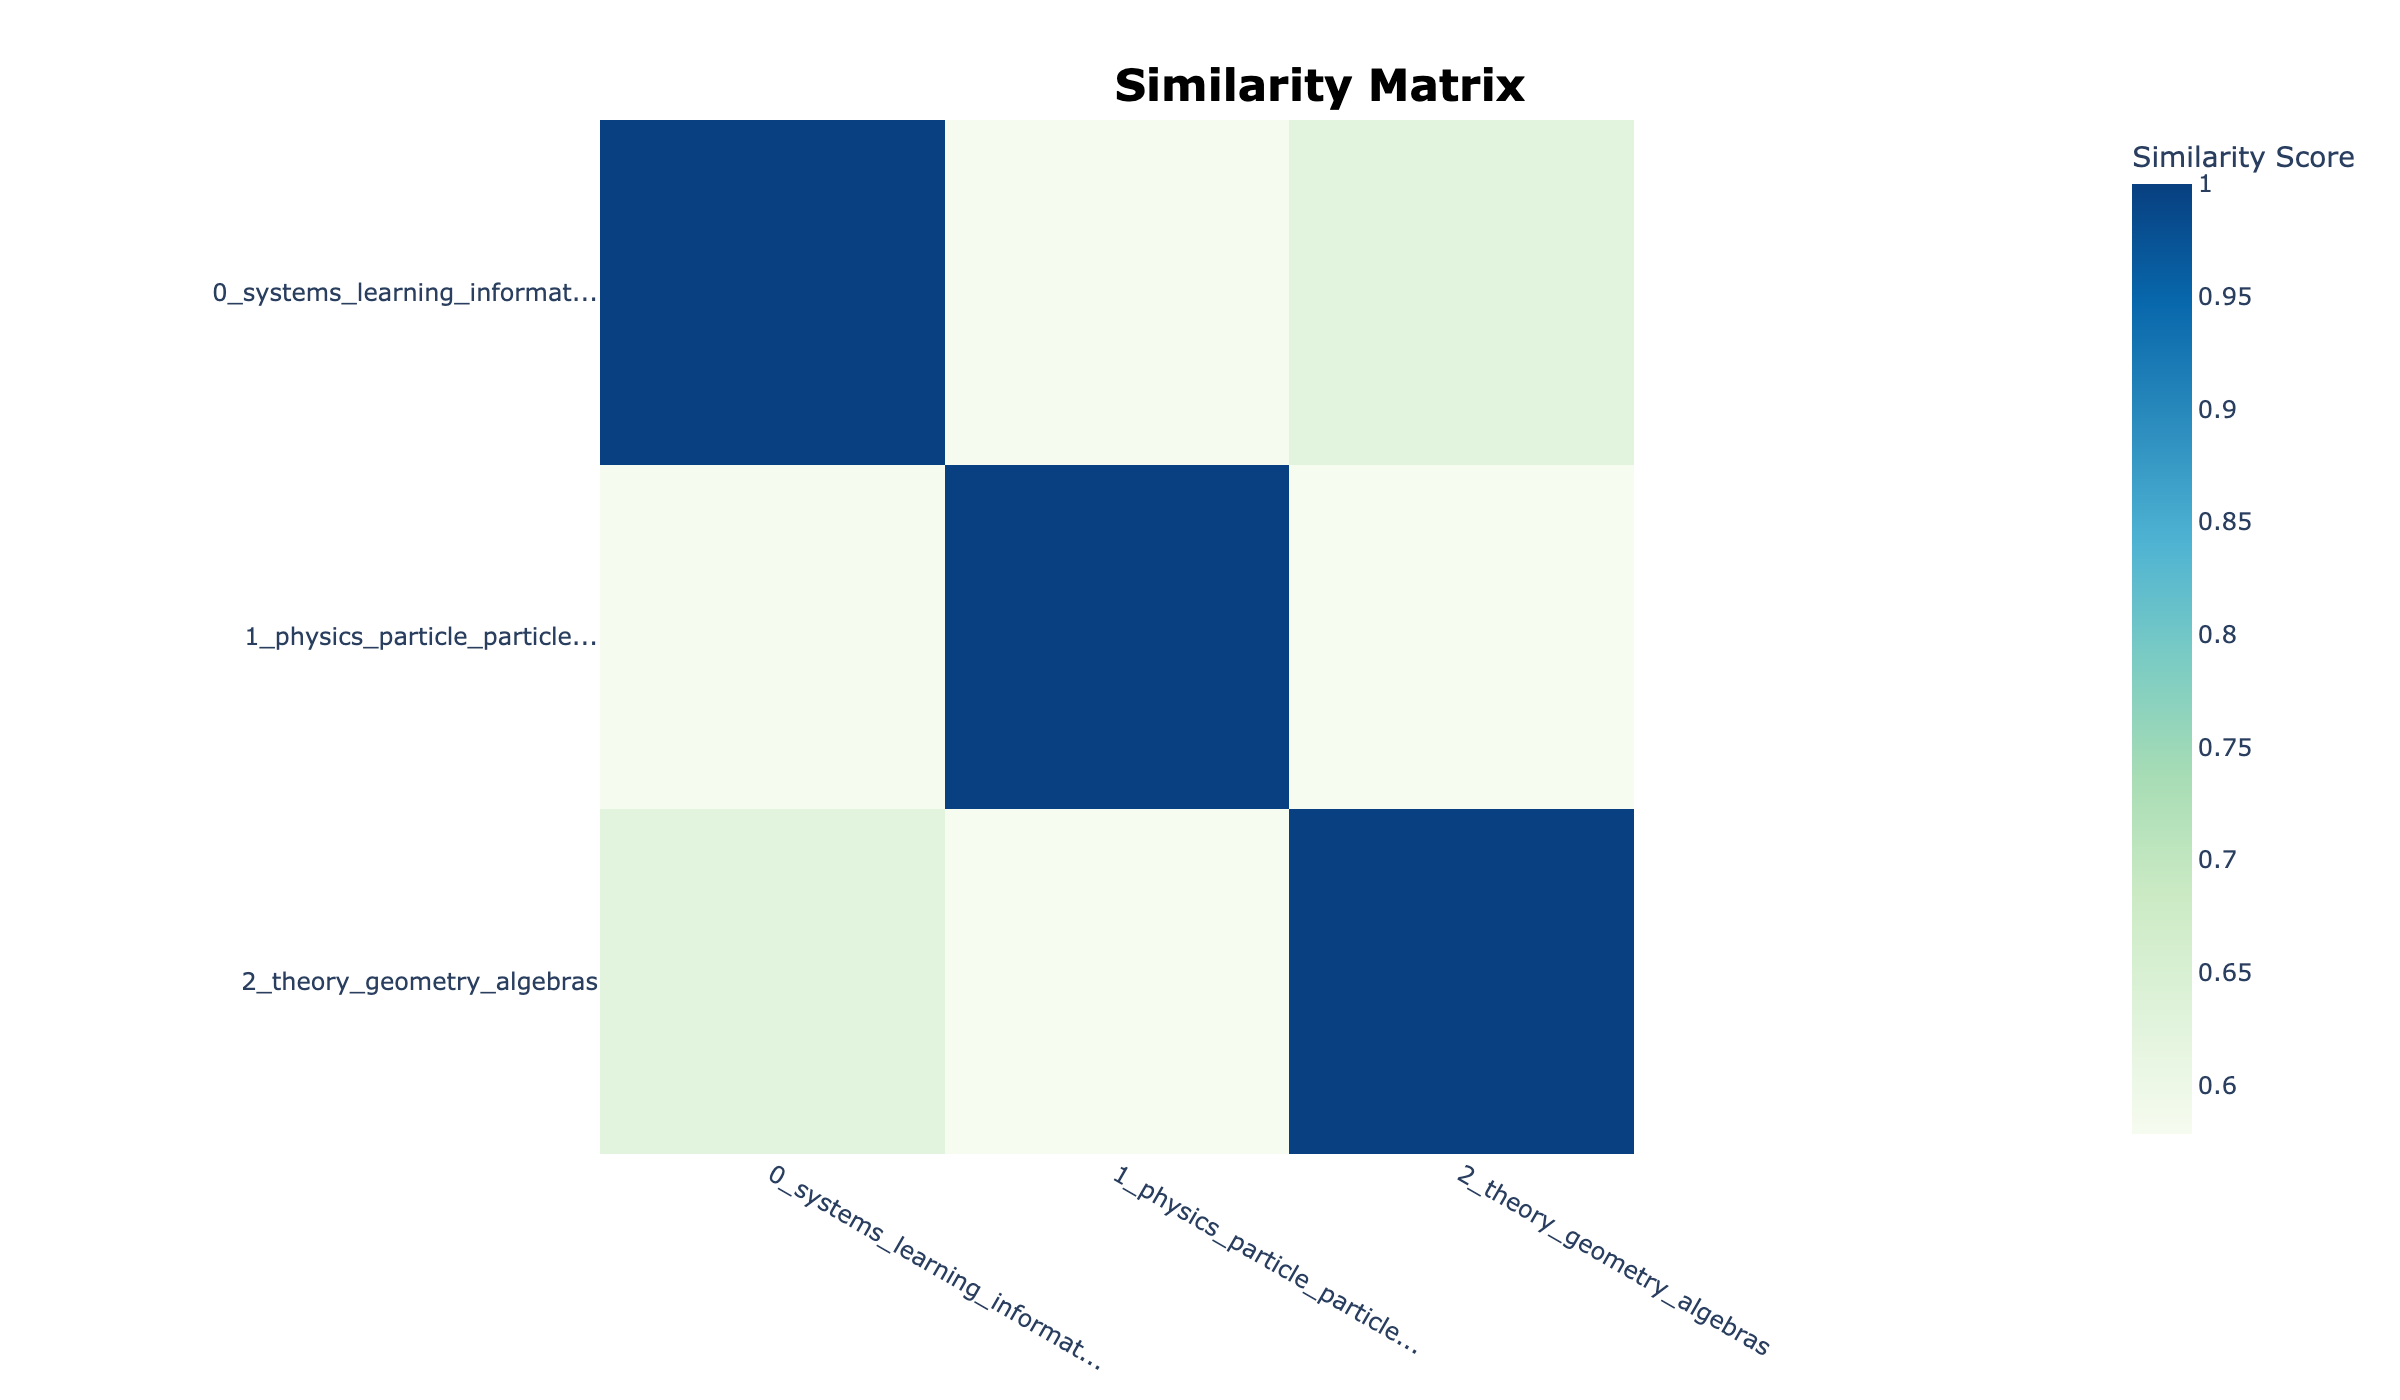

In [25]:
# Save BERTopic visualizations as HTML and PNG, display in notebook
import os
os.makedirs('figures', exist_ok=True)

if BERT_OK:
    viz_figs = {
        'bertopic_barchart': bert.visualize_barchart(top_n_topics=12),
        'bertopic_map':      bert.visualize_topics(),
        'bertopic_heatmap':  bert.visualize_heatmap(),
    }
    for name, fig in viz_figs.items():
        fig.write_html(f'figures/{name}.html')
        try:
            fig.write_image(f'figures/{name}.png', scale=2, width=1200, height=700)
            print(f'Saved: figures/{name}.html + figures/{name}.png')
        except Exception as e:
            print(f'Saved: figures/{name}.html  (PNG failed: {e})')

    # Display PNGs inline in the notebook
    from IPython.display import Image, display
    for name in viz_figs:
        png_path = f'figures/{name}.png'
        if os.path.exists(png_path):
            print(f'--- {name} ---')
            display(Image(filename=png_path, width=900))

## Comparison

In [26]:
# Comparison: LDA vs NMF top words side by side
# Use this to label your topics — read both columns together
print('LDA vs NMF — top words side by side')
print('=' * 70)
for i in range(N_TOPICS):
    lda_words = [lda_names[j] for j in lda.components_[i].argsort()[:-9:-1]]
    nmf_words = [nmf_names[j] for j in nmf.components_[i].argsort()[:-9:-1]]
    print(f'T{i+1:02d}  LDA: {" | ".join(lda_words)}')
    print(f'     NMF: {" | ".join(nmf_words)}')
    print()

LDA vs NMF — top words side by side
T01  LDA: network | water | environmental | information | health | modeling | risk | human
     NMF: learning | robot | task | machine | machine learning | human | brain | algorithm

T02  LDA: network | wireless | application | software | communication | algorithm | power | sensor
     NMF: cell | cancer | tumor | drug | tissue | protein | gene | therapy

T03  LDA: protein | function | gene | mechanism | molecular | specie | biological | cell
     NMF: theory | algebra | geometry | algebraic | quantum | algebraic geometry | symmetry | space

T04  LDA: learning | evaluation | computer | scientist | computing | resource | practice | industry
     NMF: network | wireless | communication | spectrum | algorithm | security | wireless network | networking

T05  LDA: material | energy | structure | property | magnetic | application | spin | particle
     NMF: material | magnetic | property | energy | structure | protein | spin | quantum

T06  LDA: cell | dru

In [27]:
# Comparison: cross-tab — how much do LDA and NMF agree?
# High values = both methods put the same grants in the same cluster
crosstab = pd.crosstab(aa['lda_topic'], aa['nmf_topic'],
                        rownames=['LDA'], colnames=['NMF'])
print('LDA vs NMF agreement:')
print(crosstab.to_string())
print()
# Topics may be in different order between methods
# Look for large values anywhere in the table, not just the diagonal

LDA vs NMF agreement:
NMF    0    1    2    3    4    5   6    7
LDA                                       
0      4    0    5   34   10  211   0    1
1     43    0    3  253   36   16   9  127
2      1  181    0    3   43  114   1    0
3    107    8    0   42   35  319   5  115
4      2   16    3    1  312    5  15    0
5     29  155    0    8   31   32   3    0
6    105    3    1    3    0  210   0   11
7      3    1  127    9    7    7  48    0

